In [1]:
# ==========================================================
# 1. Imports
# ==========================================================

import os
import re
import torch
import numpy as np
import torchvision
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as T
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from glob import glob
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []


# ==========================================================
# 2. Transforms (NO GABOR)
# ==========================================================

cls_transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor()
])


# ==========================================================
# 3. Label Extraction
# ==========================================================

def extract_label(name):
    if re.search("malignant", name, re.I):
        return 1
    if re.search("benign", name, re.I):
        return 0
    return -1


# ==========================================================
# 4. Dataset (RAW IMAGE ONLY)
# ==========================================================

class MammographyDataset(Dataset):
    def __init__(self, folder):
        self.files = glob(folder + "/*")

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        path = self.files[idx]
        img = Image.open(path).convert("L")   # grayscale
        img = cls_transform(img)
        label = extract_label(path)
        return img, label


# ==========================================================
# 5. Baseline Models
# ==========================================================

class LeNet5(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 6, 5),
            nn.ReLU(),
            nn.AvgPool2d(2),
            nn.Conv2d(6, 16, 5),
            nn.ReLU(),
            nn.AvgPool2d(2),
            nn.Flatten(),
            nn.Linear(16*53*53, 120),
            nn.ReLU(),
            nn.Linear(120, 84),
            nn.ReLU(),
            nn.Linear(84, 2)
        )
    def forward(self, x): return self.net(x)


def get_alexnet():
    model = torchvision.models.alexnet(weights=None)
    model.features[0] = nn.Conv2d(1, 64, 11, 4, 2)
    model.classifier[6] = nn.Linear(4096, 2)
    return model


def get_vgg19():
    model = torchvision.models.vgg19(weights=None)
    model.features[0] = nn.Conv2d(1, 64, 3, padding=1)
    model.classifier[6] = nn.Linear(4096, 2)
    return model


def get_resnet50():
    model = torchvision.models.resnet50(weights=None)
    model.conv1 = nn.Conv2d(1, 64, 7, 2, 3, bias=False)
    model.fc = nn.Linear(2048, 2)
    return model


# ==========================================================
# 6. Training Function (CLEAN BASELINE)
# ==========================================================

def train_model(model, train_loader, val_loader, name, epochs=60):

    model.to(device)

    optimizer = optim.AdamW(model.parameters(), lr=1e-4)
    ce = nn.CrossEntropyLoss()

    best_val_acc = 0

    for epoch in range(epochs):

        model.train()
        preds, gts = [], []
        total_loss = 0

        for img, label in train_loader:

            img = img.to(device, non_blocking=True)
            label = label.to(device, non_blocking=True)

            with torch.amp.autocast('cuda'):
                out = model(img)
                loss = ce(out, label)

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            preds += out.argmax(1).cpu().tolist()
            gts   += label.cpu().tolist()

        train_acc = accuracy_score(gts, preds)

        # Validation
        model.eval()
        v_preds, v_gts = [], []

        with torch.no_grad():
            for img, label in val_loader:

                img = img.to(device, non_blocking=True)

                with torch.amp.autocast('cuda'):
                    out = model(img)

                v_preds += out.argmax(1).cpu().tolist()
                v_gts   += label.tolist()

        val_acc = accuracy_score(v_gts, v_preds)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(),
                       f"/kaggle/working/{name}_best.pth")

        print(f"{name} | Epoch {epoch} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

    print(f"{name} DONE | Best Val Acc: {best_val_acc:.4f}")


# ==========================================================
# 7. Evaluation (UNCHANGED)
# ==========================================================

def evaluate(model, loader):

    model.eval()
    preds, gts = [], []

    with torch.no_grad():
        for img, label in loader:

            img = img.to(device, non_blocking=True)

            with torch.amp.autocast('cuda'):
                out1 = model(img)
                out2 = model(torch.flip(img, [3]))
                out3 = model(torch.flip(img, [2]))

            out = (out1 + out2 + out3) / 3

            preds += out.argmax(1).cpu().tolist()
            gts   += label.tolist()

    print("Accuracy:", accuracy_score(gts, preds))
    print("F1:", f1_score(gts, preds))

    cm = confusion_matrix(gts, preds)
    sns.heatmap(cm, annot=True, fmt="d",
                xticklabels=["Benign","Malignant"],
                yticklabels=["Benign","Malignant"])
    plt.show()

    print(classification_report(gts, preds))

In [2]:
# ==========================================================
# 8. DataLoaders (UNCHANGED SETTINGS)
# ==========================================================

train_loader = DataLoader(
    MammographyDataset("/kaggle/input/datasets/lilyofthevalley6666/breast-mammogphy-dataset-inbreast-database-fb/train_i"),
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)

val_loader = DataLoader(
    MammographyDataset("/kaggle/input/datasets/lilyofthevalley6666/breast-mammogphy-dataset-inbreast-database-fb/val_i"),
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)

test_loader = DataLoader(
    MammographyDataset("/kaggle/input/datasets/lilyofthevalley6666/breast-mammogphy-dataset-inbreast-database-fb/test_i"),
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)


===== Training LeNet5 =====
LeNet5 | Epoch 0 | Train Acc: 0.6623 | Val Acc: 0.7294
LeNet5 | Epoch 1 | Train Acc: 0.7254 | Val Acc: 0.7245
LeNet5 | Epoch 2 | Train Acc: 0.7426 | Val Acc: 0.7284
LeNet5 | Epoch 3 | Train Acc: 0.7482 | Val Acc: 0.7333
LeNet5 | Epoch 4 | Train Acc: 0.7577 | Val Acc: 0.7461
LeNet5 | Epoch 5 | Train Acc: 0.7685 | Val Acc: 0.7706
LeNet5 | Epoch 6 | Train Acc: 0.7987 | Val Acc: 0.7647
LeNet5 | Epoch 7 | Train Acc: 0.8150 | Val Acc: 0.7980
LeNet5 | Epoch 8 | Train Acc: 0.8493 | Val Acc: 0.7990
LeNet5 | Epoch 9 | Train Acc: 0.8651 | Val Acc: 0.8255
LeNet5 | Epoch 10 | Train Acc: 0.8869 | Val Acc: 0.8431
LeNet5 | Epoch 11 | Train Acc: 0.9075 | Val Acc: 0.8578
LeNet5 | Epoch 12 | Train Acc: 0.9180 | Val Acc: 0.8814
LeNet5 | Epoch 13 | Train Acc: 0.9423 | Val Acc: 0.8804
LeNet5 | Epoch 14 | Train Acc: 0.9474 | Val Acc: 0.9020
LeNet5 | Epoch 15 | Train Acc: 0.9602 | Val Acc: 0.9000
LeNet5 | Epoch 16 | Train Acc: 0.9694 | Val Acc: 0.8863
LeNet5 | Epoch 17 | Train Acc

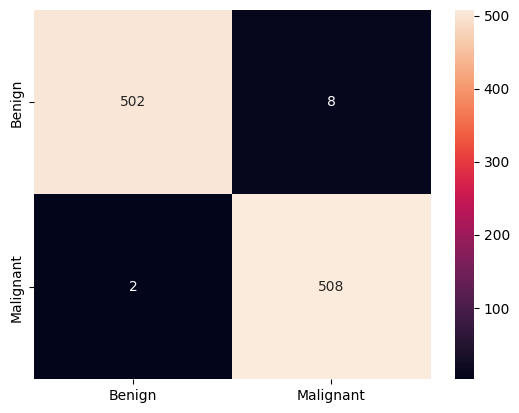

              precision    recall  f1-score   support

           0       1.00      0.98      0.99       510
           1       0.98      1.00      0.99       510

    accuracy                           0.99      1020
   macro avg       0.99      0.99      0.99      1020
weighted avg       0.99      0.99      0.99      1020


===== Training AlexNet =====
AlexNet | Epoch 0 | Train Acc: 0.6206 | Val Acc: 0.7284
AlexNet | Epoch 1 | Train Acc: 0.7321 | Val Acc: 0.7363
AlexNet | Epoch 2 | Train Acc: 0.7396 | Val Acc: 0.7373
AlexNet | Epoch 3 | Train Acc: 0.7447 | Val Acc: 0.7549
AlexNet | Epoch 4 | Train Acc: 0.7564 | Val Acc: 0.7520
AlexNet | Epoch 5 | Train Acc: 0.7600 | Val Acc: 0.7755
AlexNet | Epoch 6 | Train Acc: 0.7871 | Val Acc: 0.7686
AlexNet | Epoch 7 | Train Acc: 0.8029 | Val Acc: 0.8039
AlexNet | Epoch 8 | Train Acc: 0.8238 | Val Acc: 0.8225
AlexNet | Epoch 9 | Train Acc: 0.8547 | Val Acc: 0.8333
AlexNet | Epoch 10 | Train Acc: 0.8716 | Val Acc: 0.8255
AlexNet | Epoch 11 | Train

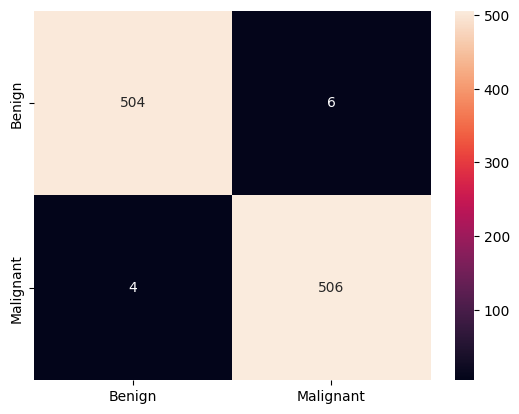

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       510
           1       0.99      0.99      0.99       510

    accuracy                           0.99      1020
   macro avg       0.99      0.99      0.99      1020
weighted avg       0.99      0.99      0.99      1020


===== Training VGG19 =====
VGG19 | Epoch 0 | Train Acc: 0.6551 | Val Acc: 0.7382
VGG19 | Epoch 1 | Train Acc: 0.7287 | Val Acc: 0.7382
VGG19 | Epoch 2 | Train Acc: 0.7314 | Val Acc: 0.7324
VGG19 | Epoch 3 | Train Acc: 0.7350 | Val Acc: 0.7275
VGG19 | Epoch 4 | Train Acc: 0.7419 | Val Acc: 0.7431
VGG19 | Epoch 5 | Train Acc: 0.7462 | Val Acc: 0.7441
VGG19 | Epoch 6 | Train Acc: 0.7438 | Val Acc: 0.7343
VGG19 | Epoch 7 | Train Acc: 0.7452 | Val Acc: 0.7500
VGG19 | Epoch 8 | Train Acc: 0.7531 | Val Acc: 0.7539
VGG19 | Epoch 9 | Train Acc: 0.7571 | Val Acc: 0.7608
VGG19 | Epoch 10 | Train Acc: 0.7616 | Val Acc: 0.7451
VGG19 | Epoch 11 | Train Acc: 0.7659 | Val Acc: 0.

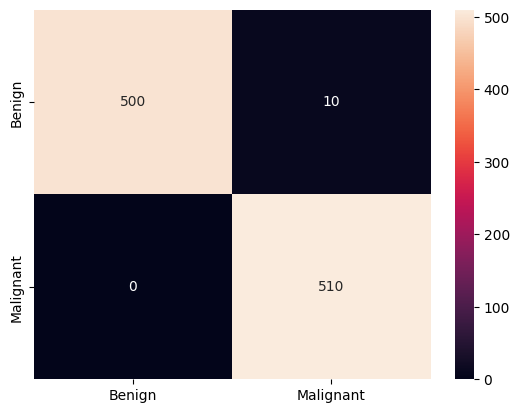

              precision    recall  f1-score   support

           0       1.00      0.98      0.99       510
           1       0.98      1.00      0.99       510

    accuracy                           0.99      1020
   macro avg       0.99      0.99      0.99      1020
weighted avg       0.99      0.99      0.99      1020


===== Training ResNet50 =====
ResNet50 | Epoch 0 | Train Acc: 0.6692 | Val Acc: 0.6794
ResNet50 | Epoch 1 | Train Acc: 0.7536 | Val Acc: 0.7941
ResNet50 | Epoch 2 | Train Acc: 0.8031 | Val Acc: 0.7206
ResNet50 | Epoch 3 | Train Acc: 0.8583 | Val Acc: 0.8176
ResNet50 | Epoch 4 | Train Acc: 0.8966 | Val Acc: 0.8676
ResNet50 | Epoch 5 | Train Acc: 0.9327 | Val Acc: 0.8696
ResNet50 | Epoch 6 | Train Acc: 0.9376 | Val Acc: 0.9039
ResNet50 | Epoch 7 | Train Acc: 0.9574 | Val Acc: 0.9059
ResNet50 | Epoch 8 | Train Acc: 0.9716 | Val Acc: 0.8363
ResNet50 | Epoch 9 | Train Acc: 0.9699 | Val Acc: 0.9020
ResNet50 | Epoch 10 | Train Acc: 0.9760 | Val Acc: 0.9029
ResNet50 | Epo

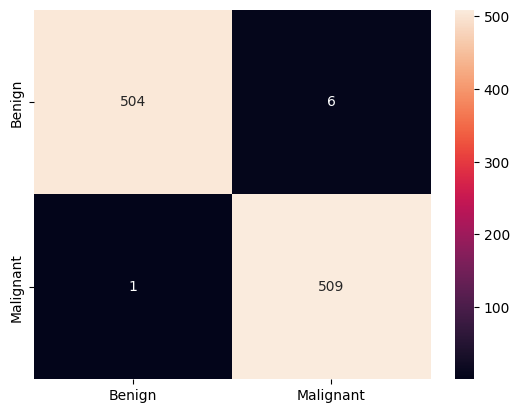

              precision    recall  f1-score   support

           0       1.00      0.99      0.99       510
           1       0.99      1.00      0.99       510

    accuracy                           0.99      1020
   macro avg       0.99      0.99      0.99      1020
weighted avg       0.99      0.99      0.99      1020

All baseline models trained & saved.


In [3]:
# ==========================================================
# 9. Main Execution (SEQUENTIAL BASELINES)
# ==========================================================

models = {
    "LeNet5": LeNet5(),
    "AlexNet": get_alexnet(),
    "VGG19": get_vgg19(),
    "ResNet50": get_resnet50()
}

for name, model in models.items():

    print(f"\n===== Training {name} =====")
    train_model(model, train_loader, val_loader, name)

    print(f"\n===== Evaluating {name} =====")
    model.load_state_dict(torch.load(f"/kaggle/working/{name}_best.pth"))
    evaluate(model, test_loader)

    torch.save(model.state_dict(),
               f"/kaggle/working/{name}_final.pth")

print("All baseline models trained & saved.")